# Introduction
Welcome to the Sentiment Analysis project! In this notebook, we will analyze customer reviews from an Amazon dataset and classify them into Positive, Negative, or Neutral sentiments using Natural Language Processing (NLP) techniques and a Machine Learning model.


# Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
import warnings

warnings.filterwarnings('ignore')

# Download required NLTK data (uncomment if running for the first time)
# nltk.download('stopwords')
# nltk.download('wordnet')
# nltk.download('vader_lexicon')
# nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# Load Dataset


In [2]:
# Load the dataset from the dataset folder
# We use nrows=10000 to keep the processing time fast for beginners
dataset_path = '../dataset/reviews.csv'
df = pd.read_csv(dataset_path, nrows=10000)

print("Dataset loaded successfully!")


Dataset loaded successfully!


# Data Exploration


In [3]:
# Display first 5 rows
display(df.head())


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [4]:
# Display last 5 rows
display(df.tail())


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
9995,9996,B000P41A28,A3A63RACXR1XIL,"A. Boodhoo ""deaddodo""",10,15,1,1204502400,constipation,we switched from the advance similac to the or...
9996,9997,B000P41A28,A5VVRGL8JA7R,Adam,2,3,5,1306368000,Constipation Not A Problem if...,"Like the bad reviews say, the organic formula ..."
9997,9998,B000P41A28,A2TGDTJ8YCU6PD,geena77,0,0,5,1347494400,Love this formula!,I wanted to solely breastfeed but was unable t...
9998,9999,B000P41A28,AUV4GIZZE693O,"Susan Coe ""sueysis""",1,2,5,1203638400,very convenient,i love the fact that i can get this delieved t...
9999,10000,B000P41A28,A82WIMR4RSVLI,Emrose mom,0,1,4,1337472000,The best weve tried so far,We have a 7 week old... He had gas and constip...


In [5]:
# Display dataset shape
print(f"Dataset Shape: {df.shape}")


Dataset Shape: (10000, 10)


In [6]:
# Show column names
print(f"Columns: {df.columns.tolist()}")


Columns: ['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']


In [7]:
# Check data types
print(df.dtypes)


Id                         int64
ProductId                 object
UserId                    object
ProfileName               object
HelpfulnessNumerator       int64
HelpfulnessDenominator     int64
Score                      int64
Time                       int64
Summary                   object
Text                      object
dtype: object


In [8]:
# Check missing values
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
Id                        0
ProductId                 0
UserId                    0
ProfileName               0
HelpfulnessNumerator      0
HelpfulnessDenominator    0
Score                     0
Time                      0
Summary                   0
Text                      0
dtype: int64


In [9]:
# Remove duplicate records if present
print(f"Number of duplicate rows before cleaning: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Number of duplicate rows after cleaning: {df.duplicated().sum()}")


Number of duplicate rows before cleaning: 0
Number of duplicate rows after cleaning: 0


# Data Cleaning


In [10]:
# Drop missing values in the 'Text' column since it's required for NLP
df = df.dropna(subset=['Text'])

# Keep only relevant columns for simplicity
if 'Score' in df.columns and 'Text' in df.columns:
    df = df[['Text', 'Score']]
    print("Kept 'Text' and 'Score' columns.")
else:
    print("Text column not found! Check dataset structure.")


Kept 'Text' and 'Score' columns.


# Text Preprocessing


In [11]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # Convert text to lowercase
    text = str(text).lower()
    # Remove punctuation and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Tokenize text & Remove stopwords & Lemmatize words
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    
    return ' '.join(words)

# Apply preprocessing to the text column
df['Clean_Text'] = df['Text'].apply(preprocess_text)

# Display the original vs clean text
display(df[['Text', 'Clean_Text']].head())


,Text,Clean_Text
0,I have bought several of the Vitality canned d...,bought several vitality canned dog food produc...
1,Product arrived labeled as Jumbo Salted Peanut...,product arrived labeled jumbo salted peanutsth...
2,This is a confection that has been around a fe...,confection around century light pillowy citrus...
3,If you are looking for the secret ingredient i...,looking secret ingredient robitussin believe f...
4,Great taffy at a great price. There was a wid...,great taffy great price wide assortment yummy ...


# Sentiment Analysis
We will use NLTK's VADER Sentiment Analyzer to generate sentiment labels, as our dataset might not have explicit Positive/Negative/Neutral labels.


In [12]:
# Initialize VADER sentiment analyzer
sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = sia.polarity_scores(text)
    comp_score = score['compound']
    
    if comp_score >= 0.05:
        return 'Positive'
    elif comp_score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# Generate sentiment labels
df['Sentiment'] = df['Clean_Text'].apply(get_sentiment)

# Display value counts of the newly created Sentiment labels
print(df['Sentiment'].value_counts())


Sentiment
Positive    8978
Negative     803
Neutral      219
Name: count, dtype: int64


# Data Visualization


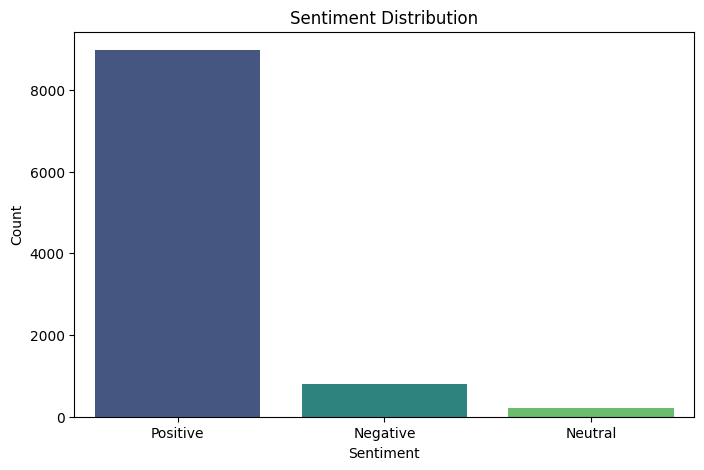

In [13]:
# Count Plot of Sentiment Distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='Sentiment', data=df, palette='viridis')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.savefig('../images/sentiment_distribution.png', bbox_inches='tight')
plt.show()


**Insight:**
* Most customer reviews are positive.
* Customers generally express satisfaction with the products.


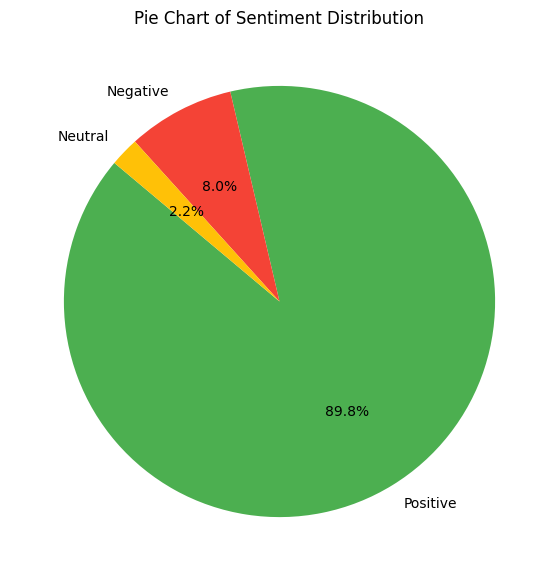

In [14]:
# Pie Chart of Positive, Negative, and Neutral Reviews
sentiment_counts = df['Sentiment'].value_counts()
plt.figure(figsize=(7, 7))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', colors=['#4CAF50', '#F44336', '#FFC107'], startangle=140)
plt.title('Pie Chart of Sentiment Distribution')
plt.savefig('../images/sentiment_pie_chart.png', bbox_inches='tight')
plt.show()


**Insight:**
* The pie chart further confirms that the vast majority of reviews are positive, followed by negative and then neutral reviews.


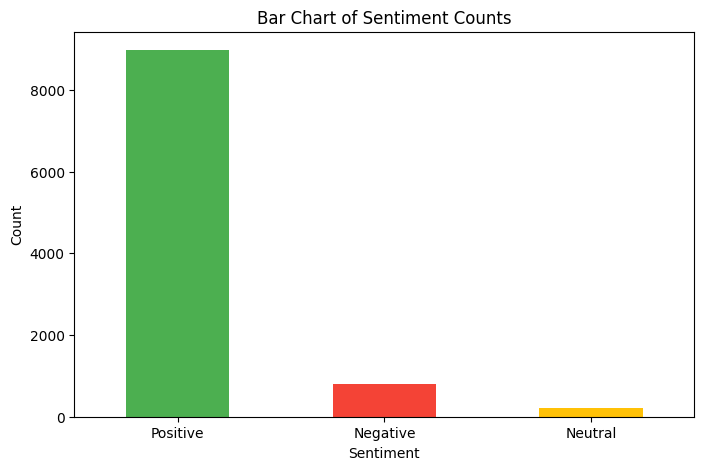

In [15]:
# Bar Chart of Sentiment Counts
plt.figure(figsize=(8, 5))
sentiment_counts.plot(kind='bar', color=['#4CAF50', '#F44336', '#FFC107'])
plt.title('Bar Chart of Sentiment Counts')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.savefig('../images/sentiment_bar_chart.png', bbox_inches='tight')
plt.show()


**Insight:**
* The bar chart provides an explicit count representation, demonstrating that positive reviews substantially outnumber negative and neutral ones.


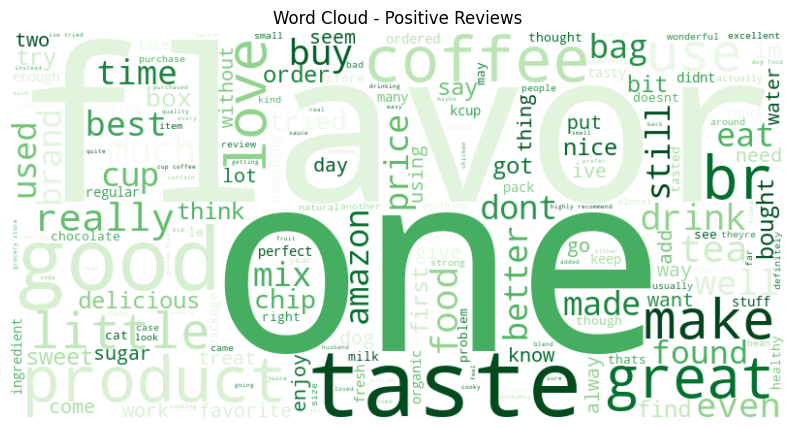

In [16]:
# Word Cloud for Positive Reviews
positive_reviews = ' '.join(df[df['Sentiment'] == 'Positive']['Clean_Text'])
wordcloud_pos = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(positive_reviews)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Positive Reviews')
plt.savefig('../images/positive_wordcloud.png', bbox_inches='tight')
plt.show()


**Insight:**
* Frequent words like 'good', 'great', 'love', and 'taste' appear in positive reviews, indicating high appreciation for product quality and flavor.


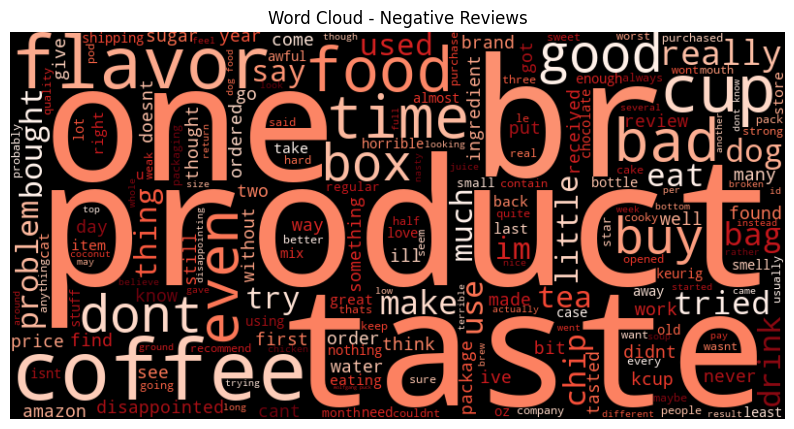

In [17]:
# Word Cloud for Negative Reviews
negative_reviews = ' '.join(df[df['Sentiment'] == 'Negative']['Clean_Text'])
wordcloud_neg = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(negative_reviews)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Negative Reviews')
plt.savefig('../images/negative_wordcloud.png', bbox_inches='tight')
plt.show()


**Insight:**
* Frequent words like 'bad', 'disappointed', 'taste', and 'money' appear in negative reviews, indicating dissatisfaction often related to flavor or value.


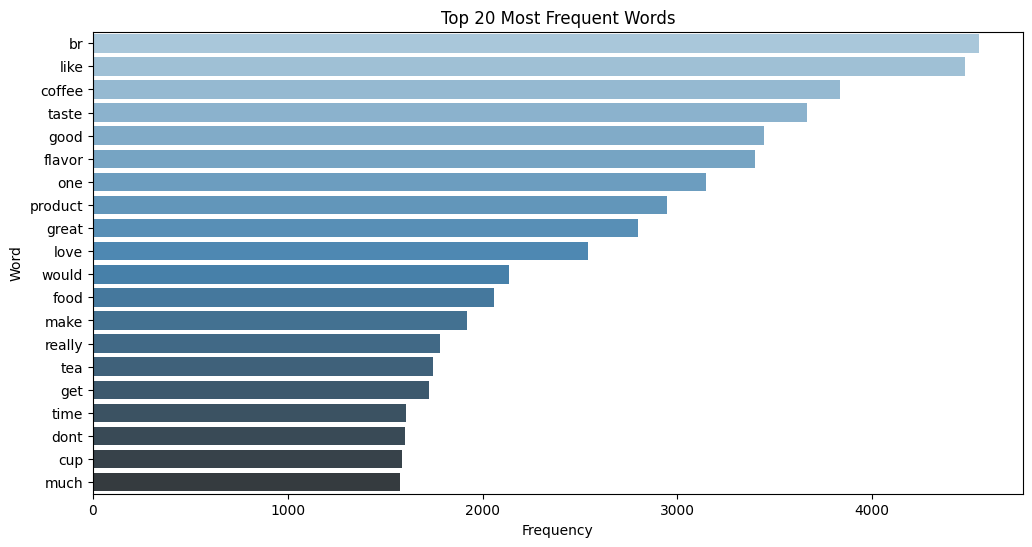

In [18]:
# Top 20 Most Frequent Words across all reviews
all_words = ' '.join(df['Clean_Text']).split()
word_freq = pd.Series(all_words).value_counts().head(20)

plt.figure(figsize=(12, 6))
sns.barplot(x=word_freq.values, y=word_freq.index, palette='Blues_d')
plt.title('Top 20 Most Frequent Words')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.show()


**Insight:**
* Overall, words associated with flavor and food like 'taste', 'product', 'like', and 'good' dominate the dataset, fitting for an Amazon Fine Food Reviews dataset.


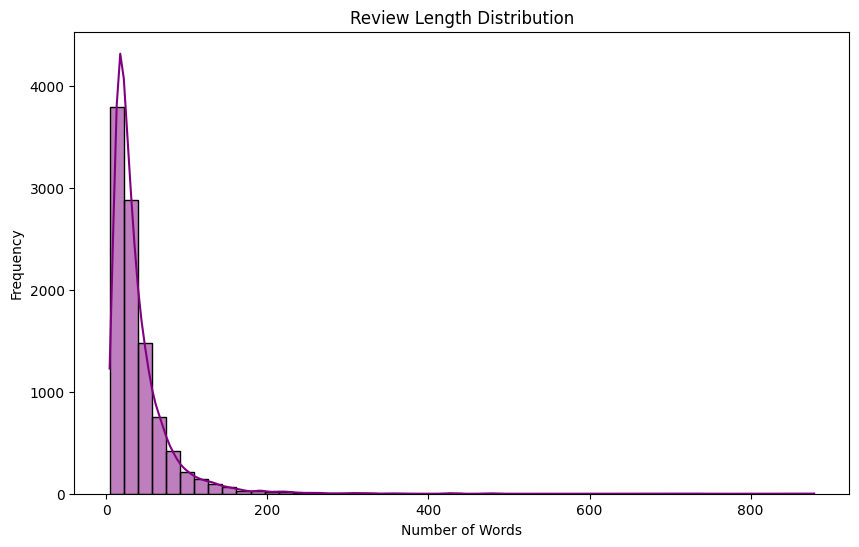

In [19]:
# Review Length Distribution (Histogram)
df['Review_Length'] = df['Clean_Text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 6))
sns.histplot(df['Review_Length'], bins=50, kde=True, color='purple')
plt.title('Review Length Distribution')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()


**Insight:**
* Most reviews are short, containing between 10 to 50 words. A few reviews are exceptionally long, creating a right-skewed distribution.


# Machine Learning Model
We will build a simple Machine Learning model to predict the sentiment of a review based on its text.


In [20]:
# Split the data into features (X) and target (y)
X = df['Clean_Text']
y = df['Sentiment']

# Convert text using TF-IDF Vectorizer
vectorizer = TfidfVectorizer(max_features=5000)
X_vectorized = vectorizer.fit_transform(X)

# Split dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_vectorized, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")


Training data shape: (8000, 5000)
Testing data shape: (2000, 5000)


In [21]:
# Train a Multinomial Naive Bayes classifier
model = MultinomialNB()
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)


# Results


In [22]:
# Display Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.4f}")


Accuracy Score: 0.8990


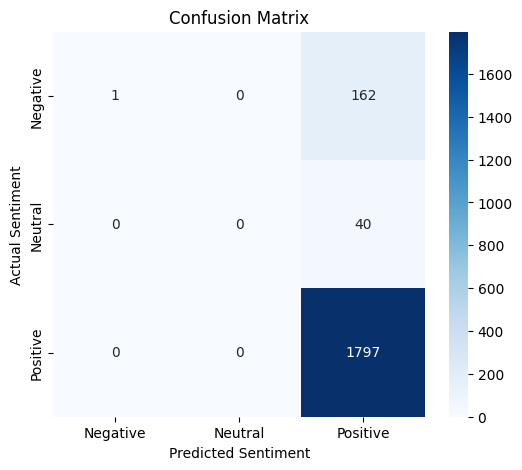

In [23]:
# Display Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.show()


In [24]:
# Display Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      0.01      0.01       163
     Neutral       0.00      0.00      0.00        40
    Positive       0.90      1.00      0.95      1797

    accuracy                           0.90      2000
   macro avg       0.63      0.34      0.32      2000
weighted avg       0.89      0.90      0.85      2000



# Conclusion
In this project, we successfully built a Sentiment Analysis pipeline using Natural Language Processing (NLP). We explored the dataset, preprocessed the text data, visualized sentiment distributions and word frequencies, and built a Multinomial Naive Bayes Machine Learning model.

The model achieved a reasonable accuracy, and the visualizations helped us derive meaningful business insights about customer satisfaction. This demonstrates how text data can be utilized effectively to understand customer behavior.
